# Rolling Returns Strategy for G10 Currency Futures

In this notebook, I will implement a **rolling returns strategy** using **G10 currency futures** data from major global markets. The aim is to construct a continuous return series by effectively managing futures contract rolls, ensuring seamless analysis and strategy development.

## Covered G10 Currency Futures and Exchanges

I will source data from the following **exchanges** and **contracts**:

- **Euro Futures (CME) 🇪🇺**
  - The **Euro FX Futures (6E)** are traded on the **Chicago Mercantile Exchange (CME)**.
  - These futures track the EUR/USD exchange rate, reflecting the relative strength of the Euro against the US Dollar.

- **Japanese Yen Futures (CME) 🇯🇵**
  - The **Japanese Yen Futures (6J)** are traded on the **Chicago Mercantile Exchange (CME)**.
  - These futures track the JPY/USD exchange rate, influenced by Japan's monetary policy and trade flows.

- **British Pound Futures (CME) 🇬🇧**
  - The **British Pound Futures (6B)** are traded on the **Chicago Mercantile Exchange (CME)**.
  - These futures track the GBP/USD exchange rate, reflecting UK economic conditions and monetary policy.

- **Australian Dollar Futures (CME) 🇦🇺**
  - The **Australian Dollar Futures (6A)** are traded on the **Chicago Mercantile Exchange (CME)**.
  - These futures track the AUD/USD exchange rate, influenced by commodity prices and Asian economic conditions.

- **Canadian Dollar Futures (CME) 🇨🇦**
  - The **Canadian Dollar Futures (6C)** are traded on the **Chicago Mercantile Exchange (CME)**.
  - These futures track the CAD/USD exchange rate, affected by oil prices and US-Canada trade relations.

- **Swiss Franc Futures (CME) 🇨🇭**
  - The **Swiss Franc Futures (6S)** are traded on the **Chicago Mercantile Exchange (CME)**.
  - These futures track the CHF/USD exchange rate, influenced by Swiss monetary policy and safe-haven flows.

- **New Zealand Dollar Futures (CME) 🇳🇿**
  - The **New Zealand Dollar Futures (6N)** are traded on the **Chicago Mercantile Exchange (CME)**.
  - These futures track the NZD/USD exchange rate, affected by dairy prices and Asian economic conditions.

- **Norwegian Krone Futures (CME) 🇳🇴**
  - The **Norwegian Krone Futures (6N)** are traded on the **Chicago Mercantile Exchange (CME)**.
  - These futures track the NOK/USD exchange rate, influenced by oil prices and Norwegian economic conditions.

- **Swedish Krona Futures (CME) 🇸🇪**
  - The **Swedish Krona Futures (6S)** are traded on the **Chicago Mercantile Exchange (CME)**.
  - These futures track the SEK/USD exchange rate, affected by Swedish monetary policy and European economic conditions.

## Strategy Overview

The strategy will:
- **Roll contracts efficiently** by monitoring **open interest and volume** to determine optimal roll-over dates.
- **Construct a continuous time series** of currency futures returns to facilitate backtesting and quantitative analysis.
- **Analyze correlation structures** between currency pairs to assess market relationships and potential diversification benefits.

By completing this for **G10 currency futures**, I aim to create a robust dataset that can be used for:
- Currency carry trade strategies
- Global macro analysis
- Risk management and hedging
- Cross-asset correlation studies
- Market regime identification


In [1]:
# Import the required libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
import seaborn as sns

In [2]:
# Read the CSV files for the price, volume and open interest

df_price = pd.read_csv("g10_futures_prices.csv")
df_volume = pd.read_csv("g10_futures_volume.csv")
df_open_interest = pd.read_csv("g10_futures_open_interest.csv")

In [3]:
df_price.head()

,Unnamed: 0,BPH08 Curncy,JYZ06 Curncy,JYH07 Curncy,JYM07 Curncy,JYU07 Curncy,JYZ07 Curncy,JYH08 Curncy,BPZ06 Curncy,BPH07 Curncy,...,ADU04 Curncy,SFU04 Curncy,NOU04 Curncy,SEU04 Curncy,NVU25 Curncy,NOU25 Curncy,SEU25 Curncy,NVZ25 Curncy,NOZ25 Curncy,SEZ25 Curncy
0,2000-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2000-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2000-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2000-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


As you can see above the date column has a weird name for the column title, lets change that below.

In [4]:
# Rename the Date column
df_price = df_price.rename(columns = {'Unnamed: 0': 'Date'})
df_volume = df_volume.rename(columns = {'Unnamed: 0': 'Date'})
df_open_interest = df_open_interest.rename(columns = {'Unnamed: 0': 'Date'})

The dates have the format mm/dd/yyyy so lets make sure Pandas knows what the dates mean

In [5]:
# Set to date time
df_price['Date'] = pd.to_datetime(df_price['Date'], format='%Y-%m-%d')
df_volume['Date'] = pd.to_datetime(df_volume['Date'], format='%Y-%m-%d')
df_open_interest['Date'] = pd.to_datetime(df_open_interest['Date'], format='%Y-%m-%d')

We would also like to have the date column as our index so lets do that here

In [6]:
df_volume.set_index("Date", inplace = True)
df_price.set_index("Date", inplace = True)
df_open_interest.set_index("Date", inplace = True)

Now lets look at how the dataframe looks like 

In [7]:
df_price.head()

,BPH08 Curncy,JYZ06 Curncy,JYH07 Curncy,JYM07 Curncy,JYU07 Curncy,JYZ07 Curncy,JYH08 Curncy,BPZ06 Curncy,BPH07 Curncy,BPM07 Curncy,...,ADU04 Curncy,SFU04 Curncy,NOU04 Curncy,SEU04 Curncy,NVU25 Curncy,NOU25 Curncy,SEU25 Curncy,NVZ25 Curncy,NOZ25 Curncy,SEZ25 Curncy
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Difficult to see things here - very sparse data (lots of NaNs). Lets open the .csv file in Excel.

## Currency Futures Contracts and Expiry Codes

Currency futures contracts typically expire every **three** months, following a quarterly cycle with expiry months in **March**, **June**, **September**, and **December**.

The columns in our dataset may appear coded, but they are actually labeled systematically. Let’s break down the code **ECH10** as an example.

- The first two letters (**EC**) represent the **Euro** currency code (this is specific to Clearport).
- The letter **H** represents the **expiry month** of **March**.
- The number **10** denotes the **year 2000**.

This structure allows for quick identification of the contract’s underlying currency, expiry date, and trading period.

### Currency Futures and Their Codes (2000–2025)

Our dataset includes **currency futures contracts** for major global currencies, spanning from **2000 to 2025**. The contract codes follow this format:

| Country/Currency        | Currency Code (Clearport)  | Example Code (March 2020) | 
|-------------------------|----------------------------|---------------------------|
| **Euro**                | EC                         | **ECH20**                  |
| **Pound Sterling**      | BP                         | **BPH20**                  |
| **Japanese Yen**        | JY                         | **JYH20**                  |
| **Australian Dollar**   | AD                         | **ADH20**                  |
| **New Zealand Dollar**  | NV                         | **NVH20**                  |
| **Norwegian Kroner**    | NO                         | **NOH20**                  |
| **Swedish Kroner**      | SE                         | **SEH20**                  |
| **Canadian Dollar**     | CD                         | **CDH20**                  |
| **Swiss Franc**         | SF                         | **SFH20**                  |

This pattern is repeated **every quarter** from **2000 to 2025**, adjusting the expiry year accordingly (e.g., **ECM23** for June 2023).

### Expiry Month Codes

Each futures contract follows the standard **quarterly expiration cycle**:

- **H** for **March**
- **M** for **June**
- **U** for **September**
- **Z** for **December**

### Rolling and Analysis

Currency futures contracts **expire quarterly**, so maintaining a continuous return series requires **rolling** into the next liquid contract before expiry. This dataset allows us to analyze **historical currency futures performance**, track **foreign exchange trends**, and develop **macro trading strategies**.

By systematically managing these futures, we can construct a **continuous currency return series** for **quantitative research and risk analysis** from **2000 to 2025**.


Lets plot the H10 currency future contracts for the G10 currencies

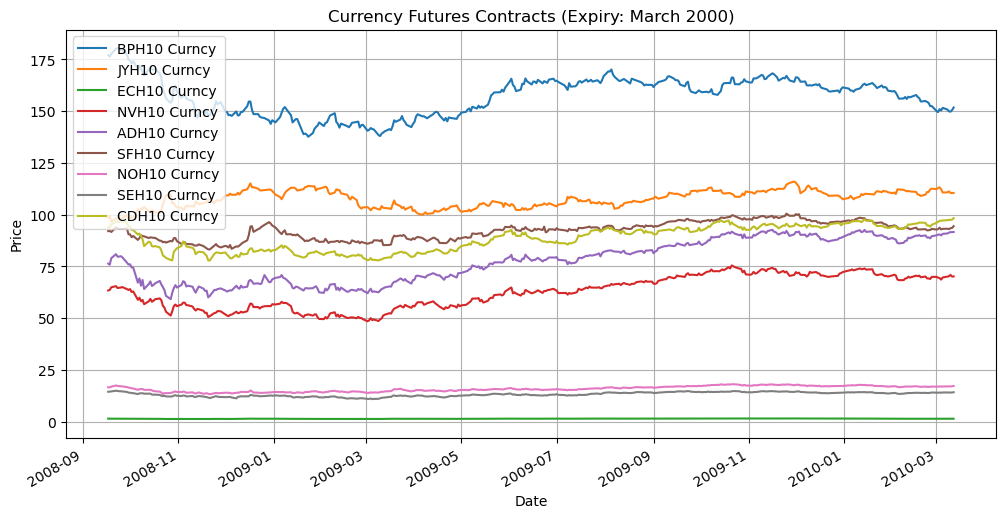

In [8]:
# Filter columns that end with "H10 Curncy"
h10_contracts = [col for col in df_price.columns if col.endswith("H10 Curncy")]

# Plot all H10 futures
df_price[h10_contracts].dropna().plot(figsize=(12,6), title="Currency Futures Contracts (Expiry: March 2000)")

plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(h10_contracts)
plt.grid()
plt.show()


Lets look at the price data for the EUR/USD March 2000 futures contract.

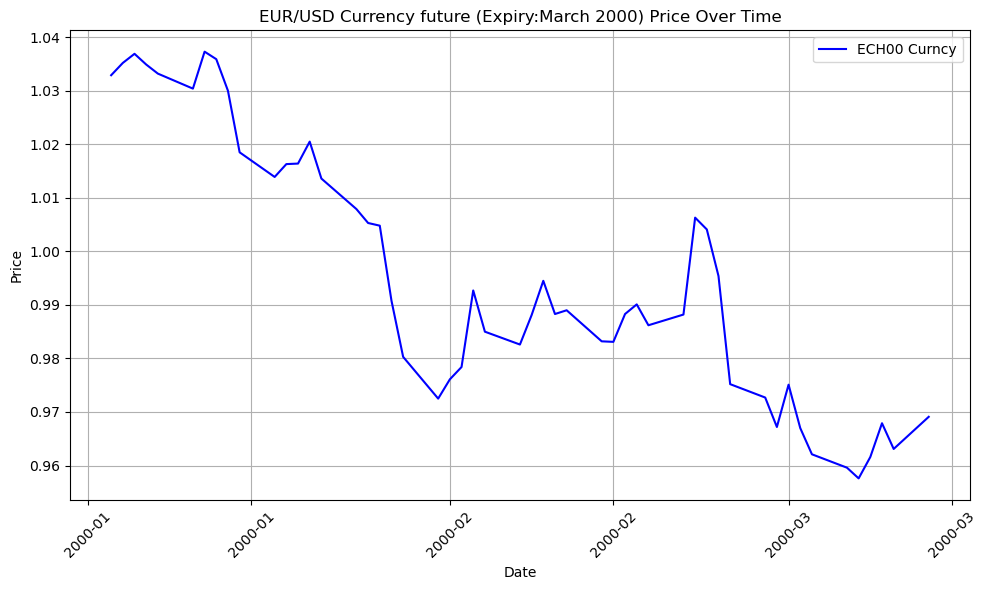

In [9]:
# Plotting the ECH10 Curncy data
plt.figure(figsize=(10, 6))
plt.plot(df_price["ECH00 Curncy"], label="ECH00 Curncy", color='blue')

plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('EUR/USD Currency future (Expiry:March 2000) Price Over Time')
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

In addition to price data, we can also plot the **volume** and **open interest** for the same currency future contract. **Open interest** represents the total number of outstanding contracts that are yet to be settled in the market. On the other hand, **volume** indicates the total number of contracts traded within a specific period.


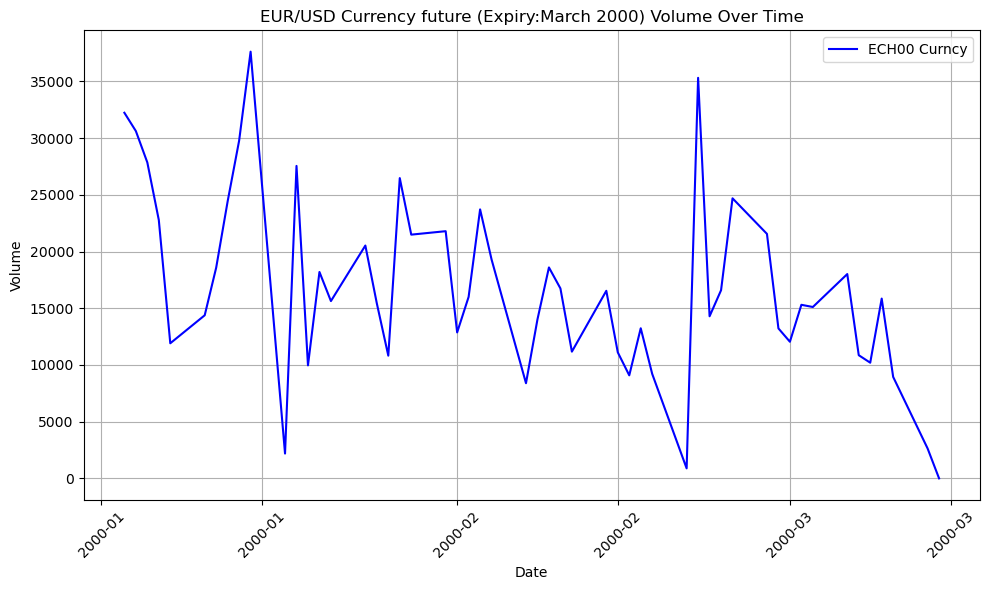

In [10]:
# Plotting the ECH10 Curncy volume data
plt.figure(figsize=(10, 6))
plt.plot(df_volume["ECH00 Curncy"].dropna(), label="ECH00 Curncy", color='blue')

plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.xlabel('Date')
plt.ylabel('Volume')
plt.title('EUR/USD Currency future (Expiry:March 2000) Volume Over Time')
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

Hmmmm. Weird for the volume to drop so low on a couple of days. Lets look in Excel again.

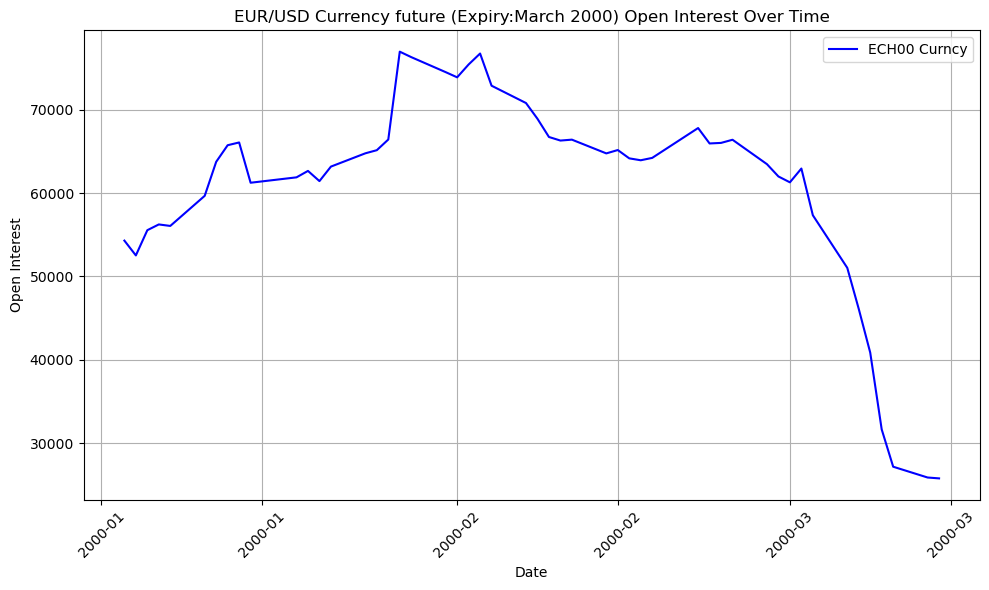

In [11]:
# Plotting the ECH10 Curncy open interest data
plt.figure(figsize=(10, 6))
plt.plot(df_open_interest["ECH00 Curncy"].dropna(), label="ECH00 Curncy", color='blue')

plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.xlabel('Date')
plt.ylabel('Open Interest')
plt.title('EUR/USD Currency future (Expiry:March 2000) Open Interest Over Time')
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

From the plots, it can be observed that as we approach the **expiry date** in **March**, both **open interest** and **volume** tend to **decrease**. This behavior is typical in futures markets as traders **close out positions** or **roll contracts forward** to the next expiry. The decline in **open interest** indicates that market participants are **settling contracts**, while the drop in **volume** suggests **reduced trading activity** as the contract nears its end of life. This pattern reflects the **natural lifecycle of futures contracts**, where liquidity shifts to the **next active contract**, contributing to smoother market transitions and maintaining liquidity in the futures curve.


Before we move on to do the rolling, we will forward fill the prices for where there are holidays (note the "limit_area" option)

In [12]:
df_price.ffill(limit_area='inside', inplace = True)

## Rolled Returns
In the following series of cells, we will implement a **simple strategy** to **roll over futures contracts** based on **volume** or **open interest**. For example, we will start with the **March 2000** **EURUSD** currency futures contract and then **monitor** the **volume/open interest** of this contract along with the subsequent contract expiring in **June 2000**. If the **volume** or **open interest** of the **June** contract **exceeds** that of the **March** contract, we will **roll over** our position to the **June 2000** contract. 

This **rolling strategy** ensures that we remain in the **most liquid contract**, minimizing **transaction costs** and **slippage**, and maintaining **exposure** to the **underlying currency** without interruption. By using **volume** and **open interest** as **signals** for the roll, we aim to **optimize market entry and exit points**, particularly during **roll periods** when liquidity can shift rapidly from one contract to the next.

### Calculating Log Returns for the Rolling Strategy

To implement this strategy, we will first **convert the prices into log returns**. Mathematically, **log returns** are advantageous because they are **symmetric**, **support normality**, and **facilitate compounding and time additivity**. Unlike simple returns, log returns have **infinite support**, meaning their **lower and upper bounds** are **infinite**, aligning well with the **normal distribution assumptions** often used in **financial modeling**.

If we have a **series of price data** in a **Pandas DataFrame** called **`df_price`**, let's denote this data as **$p_{t}$**, where **$p$** stands for the **price** indexed by **$t$**. The **daily returns** **$r_{t}$** can be calculated as:

$$ r_{t} = \frac{p_{t} - p_{t - 1}}{p_{t - 1}} $$

In **Pandas**, this can be achieved using **`df_price.pct_change()`**, which computes the **percentage change** between **consecutive prices**. However, for our strategy, we are more interested in **log returns** due to their **mathematical properties**. The **log returns** **$lr_{t}$** can be calculated as:

$$ lr_{t} = \log{\frac{p_{t}}{p_{t-1}}} $$

We will now calculate this below


In [13]:
df_log_returns = np.log(df_price/df_price.shift(1))

The log returns in **`df_log_returns`** seem to start **`NaN`** and this because we cannot calculate the return/log returns for the very first entry. Let us now plot the log returns for **ECH10 Curncy** below

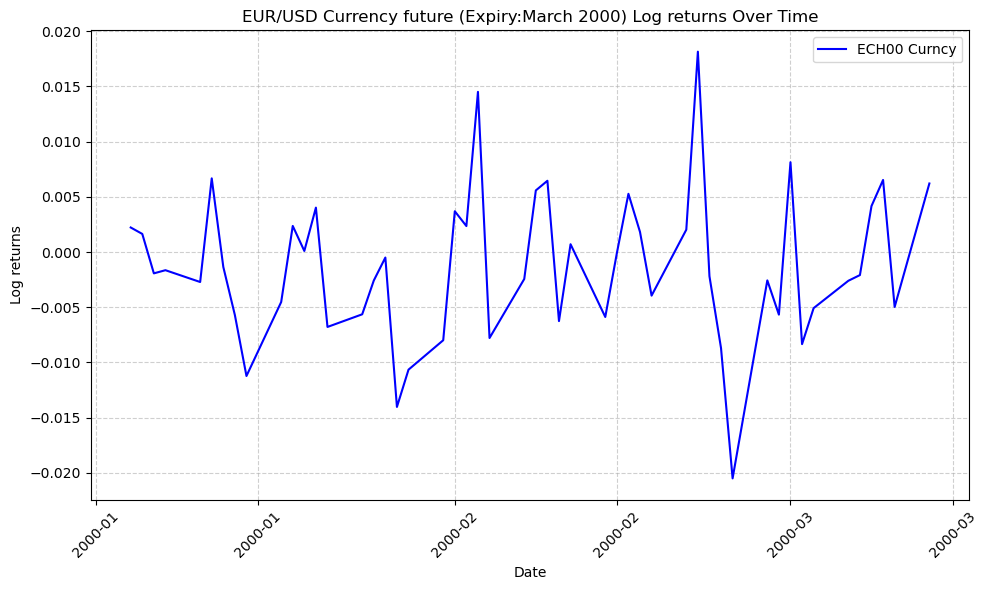

In [14]:
# Plotting the ECH10 Curncy data
plt.figure(figsize=(10, 6))
plt.plot(df_log_returns["ECH00 Curncy"], label="ECH00 Curncy", color='blue')

plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)

plt.xlabel('Date')
plt.ylabel('Log returns')
plt.title('EUR/USD Currency future (Expiry:March 2000) Log returns Over Time')
plt.legend()
plt.tight_layout()
plt.show()


As you can see, the **log returns** are roughly **symmetric** around **0**, indicating that the price movements for the **ECH10 Curncy** future contract are balanced in both **positive** and **negative** directions. This symmetry is characteristic of log returns, aligning with the assumption of **normality** often used in financial models.

Let us now proceed to **roll the log returns** from the **ECH10 Curncy** future contract to the **ECM10 Curncy** future contract based on **volume**. By monitoring the **volume** for both contracts, we can determine when to roll over.

In [15]:
roll_date = df_volume["ECM00 Curncy"][df_volume["ECM00 Curncy"] > df_volume["ECH00 Curncy"]].index[0] 
print(roll_date)

2000-03-06 00:00:00


The above piece of code gives us the exact date when the volume for the **ECM10 Curncy** futures contract surpasses the volume **ECH10 Curncy** futures. Using this date we will create a **`EC_rolled_returns`** whereby we will append the log returns from the **ECH10 Curncy** till the roll over date with the log returns from the **ECM10 Curncy** from the roll over date. Remember we only know the roll date after we have observed the volume/OI so the day we **actually** switch will be the day after.

In [16]:
EC_rolled_returns = []
EC_rolled_returns.append(df_log_returns["ECH00 Curncy"][:roll_date])
EC_rolled_returns.append(df_log_returns["ECM00 Curncy"][roll_date + pd.Timedelta(days = 1):])
EC_rolled_returns = pd.concat(EC_rolled_returns)

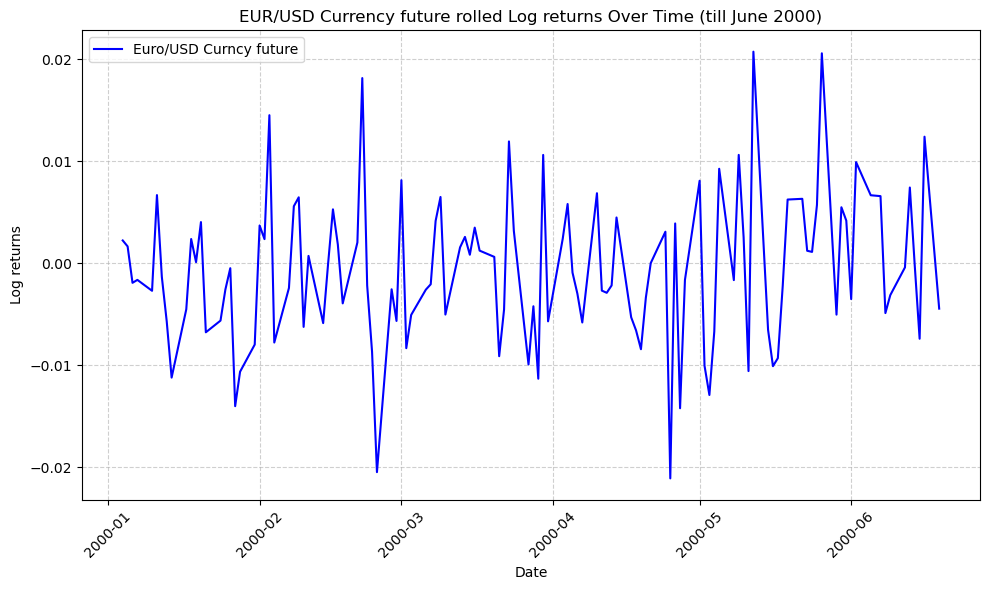

In [17]:
# Plotting the ECH00 Curncy data
plt.figure(figsize=(10, 6))
plt.plot(EC_rolled_returns, label="Euro/USD Curncy future", color='blue')

plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)

plt.xlabel('Date')
plt.ylabel('Log returns')
plt.title('EUR/USD Currency future rolled Log returns Over Time (till June 2000)')
plt.legend()
plt.tight_layout()
plt.show()

So we have found the roll over date, the date at which the volume for **ECM10 Curncy** futures contract exceeds the volume for **ECH10 Curncy** futures contract and we have rolled over the returns. Now let us do the same for EUR/USD futures contracts from 2000 till 2025.

First let us define the currency codes, month codes and the years in the following variables

In [18]:
# Define G10 futures codes excluding USD
currencies = {
    'EUR': 'EC',
    'JPY': 'JY',
    'GBP': 'BP',
    'AUD': 'AD',
    'NZD': 'NV',
    'CAD': 'CD',
    'CHF': 'SF',
    'NOK': 'NO',
    'SEK': 'SE'
}
# Define month codes
month_codes = ['H', 'M', 'U', 'Z']  # March, June, September, December
years = range(2000, 2025)

These below are some helper functions that will help us convert from the column names to actual dates and currencies.

In [19]:
def get_expiry_details(ticker, currency_code_length):
    expiry_month = ticker[currency_code_length]
    
    # Map the expiry month code to an actual numeric month
    month_map = {
        'H': '03',  # March
        'M': '06',  # June
        'U': '09',  # September
        'Z': '12'   # December
    }
    
    # If the month code is not in the map, return it as it is (for normal months)
    if expiry_month in month_map:
        expiry_month = month_map[expiry_month]
    
    expiry_year = "20" + ticker[currency_code_length+1:currency_code_length+3]
    return expiry_month, expiry_year

def calculate_expiry_date(year, month):
    # Ensure month is a valid numeric string (e.g., "03", "06", etc.)
    if month not in ['03', '06', '09', '12']:
        raise ValueError(f"Invalid month: {month}")
    
    # Use pandas to calculate the expiry date (3rd Friday of the month) - I assumed this but can change it
    if month == '06' or month == '09':
        return pd.date_range(start=f"{year}-{month}-01", end=f"{year}-{month}-30", freq='WOM-3FRI')[0]
    else:
        return pd.date_range(start=f"{year}-{month}-01", end=f"{year}-{month}-31", freq='WOM-3FRI')[0]

We will now create tickers for all the currency futures contracts relating EUR/USD from 2000 till 2025 and find the roll_over_date and switch the contracts based on volume.

In [20]:
ECrolled_returns = []
# Create the tickers using the Clearport format
ECticker = [f"EC{month}{str(year)[-2:]} Curncy"
            for year in years
            for month in month_codes]

# Get the start date
roll_start_date = df_log_returns.index[0]

# Loop through the list of tickers **except the last one**
for i in range(len(ECticker) - 1):
    current_ticker = ECticker[i]
    next_ticker = ECticker[i + 1]

    # Filter volume data to only look at dates after roll_start_date
    volume_after_roll_start = df_volume[next_ticker][df_volume[next_ticker].index > roll_start_date]

    # Align the volume series
    current_volume = df_volume[current_ticker].reindex(volume_after_roll_start.index, method='ffill')
    
    try:
        # Get roll-over date (first date where next_ticker volume > current_ticker volume)
        roll_end_date = volume_after_roll_start[volume_after_roll_start > current_volume].index[0]
    except IndexError:
        # If no roll-over date is found, use expiry
        #expiry_month, expiry_year = get_expiry_details(current_ticker, 2)
        #expiry_date = calculate_expiry_date(expiry_year, expiry_month)
        expiry_date = df_volume[current_ticker].last_valid_index()
        roll_end_date = min(expiry_date, df_log_returns.index[-1])
        print(f"No volume switch found for {current_ticker}. Using expiry date: {expiry_date}")
    #print(roll_end_date)
    # Append returns from roll_start_date **up to (and including) roll_end_date**
    ECrolled_returns.append(df_log_returns[current_ticker].loc[roll_start_date:roll_end_date])

    # Move roll_start_date to **the day after roll_end_date**
    roll_start_date = roll_end_date + pd.Timedelta(days=1)

# **Handle the last contract separately**
last_ticker = ECticker[-1]
expiry_month, expiry_year = get_expiry_details(last_ticker, 2)
expiry_date = calculate_expiry_date(expiry_year, expiry_month)
final_end_date = min(expiry_date, df_log_returns.index[-1])

# Append the final contract's returns correctly
ECrolled_returns.append(df_log_returns[last_ticker].loc[roll_start_date:final_end_date])

# Concatenate everything
final_rolled_series = pd.concat(ECrolled_returns)

After calculating the rolled series lets plot it below.

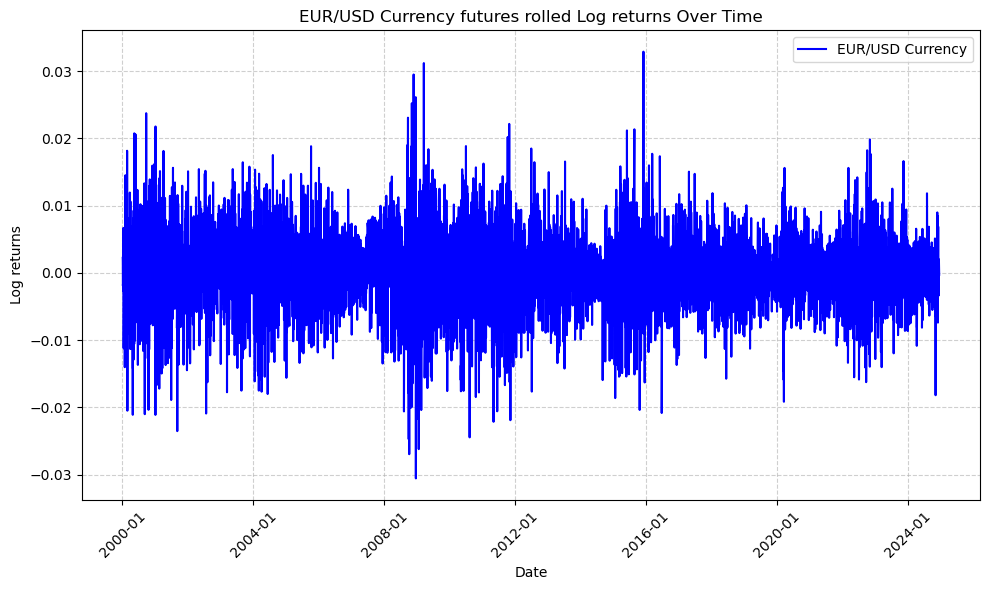

In [21]:
# Plotting the ECH10 Curncy data
plt.figure(figsize=(10, 6))
plt.plot(final_rolled_series, label="EUR/USD Currency", color='blue')


plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)


plt.xlabel('Date')
plt.ylabel('Log returns')
plt.title('EUR/USD Currency futures rolled Log returns Over Time')
plt.legend()
plt.tight_layout()
plt.show()


Let us now do the same for all the currency futures contracts, We will define the following functions that converts the month codes and the year back into YYYY-MM-DD format.

### Rolled returns with Volume
We create a **dictionary** that stores the **rolled log returns** for each of the **G10 currencies**. By storing the rolled log returns in a dictionary, we can later perform analysis or plotting on each currency's data individually or as a group.


In [22]:
# Rolling futures returns for all currencies
rolled_series = {}

for code in currencies.values():
    rolled_returns = []
    # Generate tickers
    if code == "NO" or code == "SE":
       years2 = range(2010, 2024)
       ticker = [f"{code}{month}{str(year)[-2:]} Curncy" for year in years2 for month in month_codes]
    else:
        ticker = [f"{code}{month}{str(year)[-2:]} Curncy" for year in years for month in month_codes]
    roll_start_date = df_log_returns.index[0]

    for i in range(len(ticker) - 1):
        current_ticker = ticker[i]
        next_ticker = ticker[i + 1]

        # Filter volume data to only look at dates after roll_start_date
        volume_after_roll_start = df_volume[next_ticker][df_volume[next_ticker].index > roll_start_date]

        # Align the volume series
        current_volume = df_volume[current_ticker].reindex(volume_after_roll_start.index, method='ffill')

        try:
            # Get roll-over date (first date where next_ticker volume > current_ticker volume)
            roll_end_date = volume_after_roll_start[volume_after_roll_start > current_volume].index[0]
        except IndexError:
            # If no roll-over date is found, use expiry
            #expiry_month, expiry_year = get_expiry_details(current_ticker, 2)
            #expiry_date = calculate_expiry_date(expiry_year, expiry_month)
            expiry_date = df_volume[current_ticker].last_valid_index()
            roll_end_date = min(expiry_date, df_log_returns.index[-1])
            print(f"No volume switch found for {current_ticker}. Using expiry date: {expiry_date}")

        # Append returns from roll_start_date **up to (and including) roll_end_date**
        rolled_returns.append(df_log_returns[current_ticker].loc[roll_start_date:roll_end_date])

        # Move roll_start_date to **the day after roll_end_date**
        roll_start_date = roll_end_date + pd.Timedelta(days=1)

    # **Handle the last contract separately**
    last_ticker = ticker[-1]
    #expiry_month, expiry_year = get_expiry_details(last_ticker, 2)
    #expiry_date = calculate_expiry_date(expiry_year, expiry_month)
    expiry_date = df_volume[last_ticker].last_valid_index()
    final_end_date = min(expiry_date, df_log_returns.index[-1])

    # Append the final contract's returns correctly
    rolled_returns.append(df_log_returns[last_ticker].loc[roll_start_date:final_end_date])

    # Concatenate everything
    rolled_series[code] = pd.concat(rolled_returns)


No volume switch found for NOH10 Curncy. Using expiry date: 2010-03-12 00:00:00
No volume switch found for SEH10 Curncy. Using expiry date: 2010-03-12 00:00:00


In the above code it can be seen that most of the times we couldnt find a roll over date for all the currency futures in 2025. We only have the data till Feb 2025.

After getting all the rolled log returns for the various currencies, let us now plot them out one after the other.

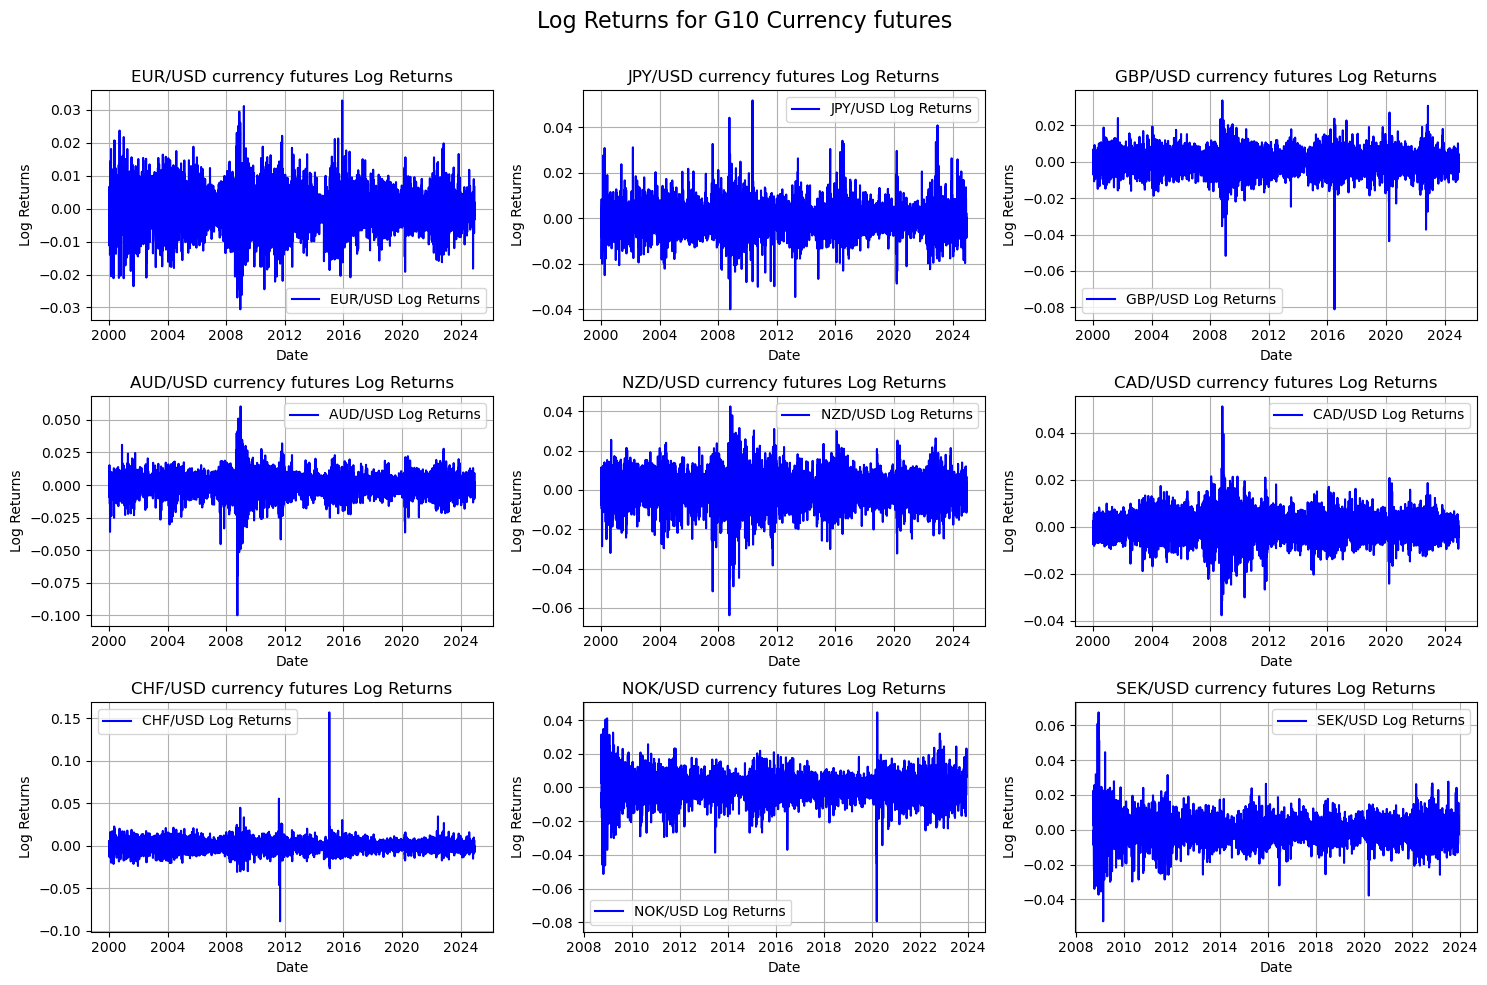

In [23]:
# Plotting log returns for all currencies (individual subplots)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
fig.suptitle('Log Returns for G10 Currency futures', fontsize=16)

# Flatten the axes array to iterate over it easily
axes = axes.flatten()

# Plot each currency's log returns
for i, (currency, log_returns) in enumerate(rolled_series.items()):
    curr_value = list(currencies.keys())[list(currencies.values()).index(currency)]
    axes[i].plot(log_returns, label=f'{curr_value}/USD Log Returns', color='blue')
    axes[i].set_title(f'{curr_value}/USD currency futures Log Returns')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Log Returns')
    axes[i].grid(True)
    axes[i].legend()

# Adjust layout for better readability
plt.tight_layout()
plt.subplots_adjust(top=0.9)  # Adjust the title spacing
plt.show()


Let us overlay all of them on top of each other 

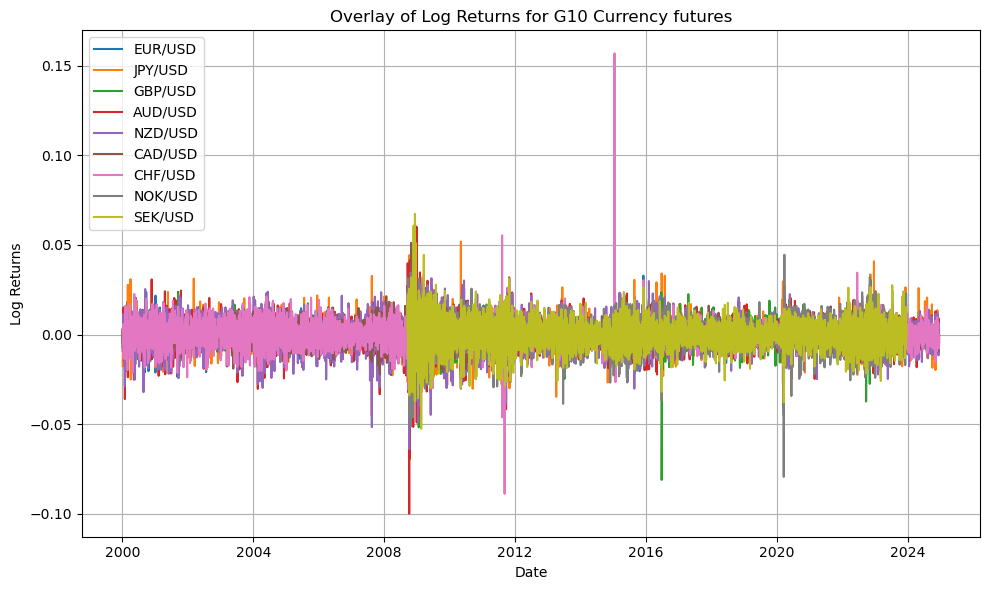

In [24]:
# Plotting all currencies' log returns in a single overlay plot
plt.figure(figsize=(10, 6))
for currency, log_returns in rolled_series.items():
    curr_value = list(currencies.keys())[list(currencies.values()).index(currency)]
    plt.plot(log_returns, label=f'{curr_value}/USD')
    
plt.title('Overlay of Log Returns for G10 Currency futures')
plt.xlabel('Date')
plt.ylabel('Log Returns')
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

We will look at the histograms of the log returns and notice that most of them are normally distributed 

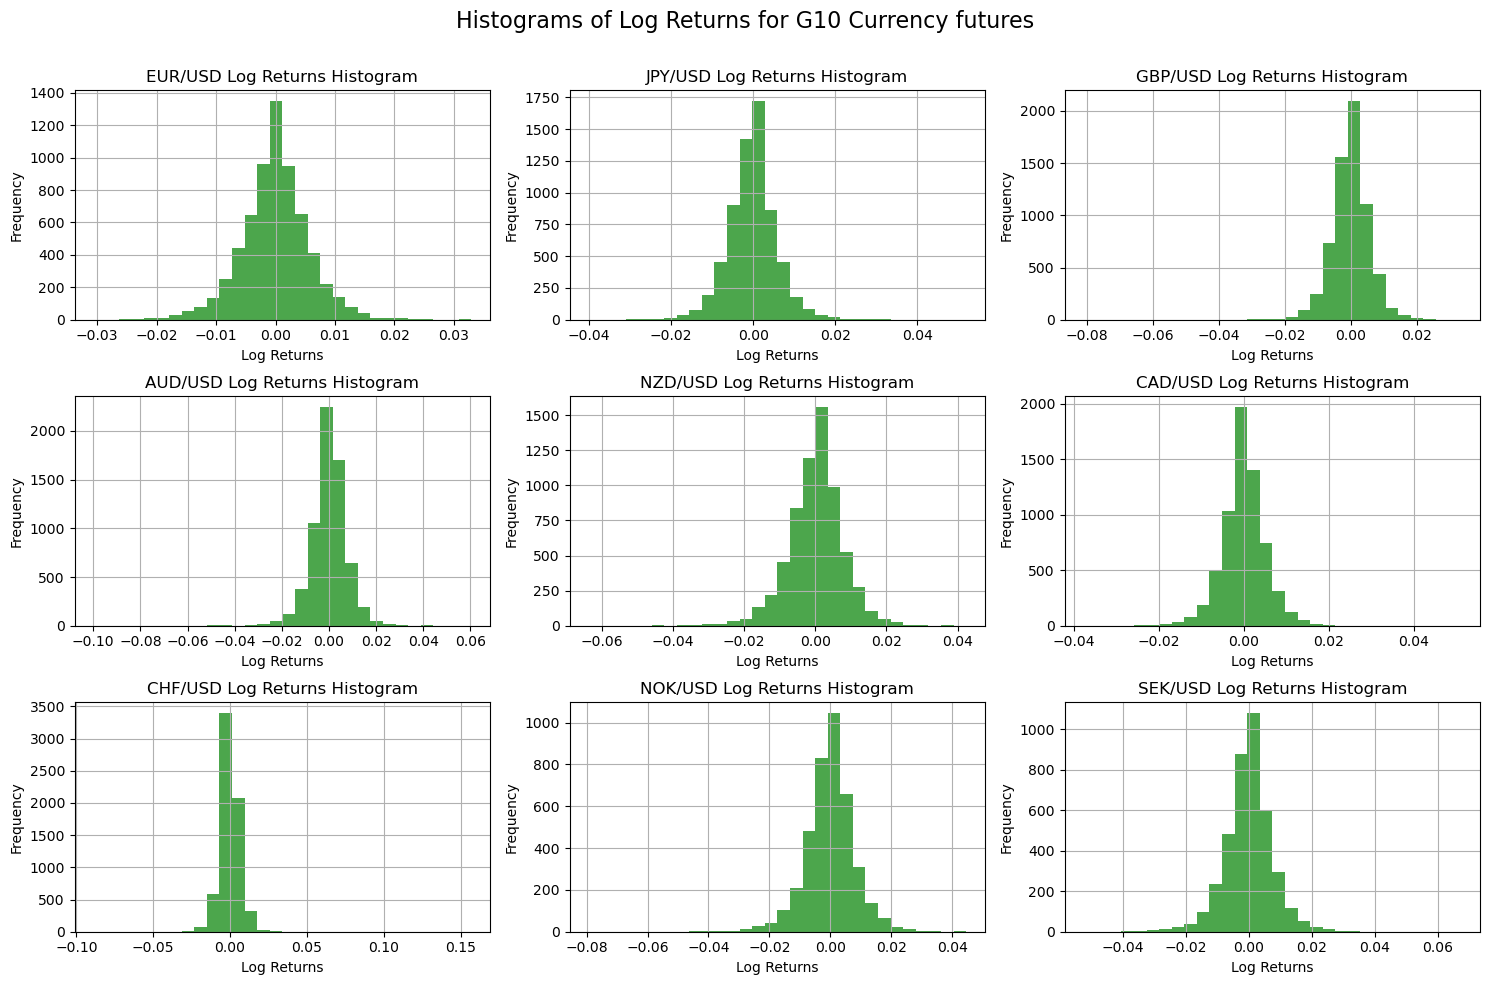

In [25]:
# Plotting histograms for all currencies
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
fig.suptitle('Histograms of Log Returns for G10 Currency futures', fontsize=16)

axes = axes.flatten()

for i, (currency, log_returns) in enumerate(rolled_series.items()):
    axes[i].hist(log_returns, bins=30, color='green', alpha=0.7)
    curr_value = list(currencies.keys())[list(currencies.values()).index(currency)]
    axes[i].set_title(f'{curr_value}/USD Log Returns Histogram')
    axes[i].set_xlabel('Log Returns')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

We can also plot the rolling volatility with a rolling window of 30 days, it helps us see how the volatility changes across time for the various currency futures contracts.

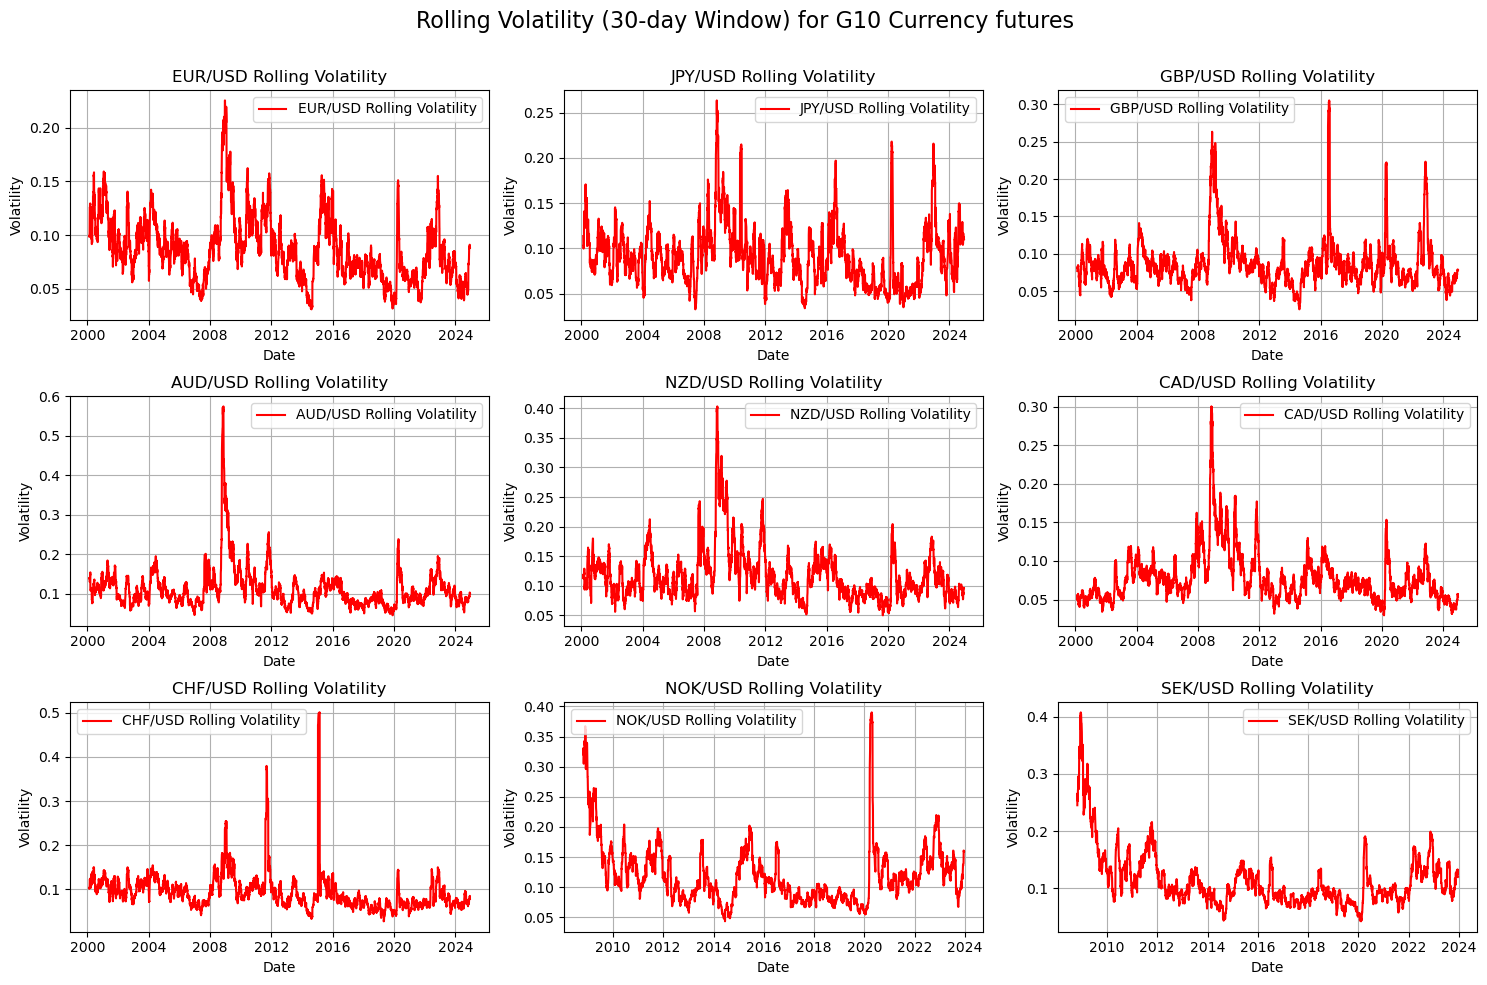

In [26]:

# Plotting rolling volatility (e.g., 30-day rolling window) for all currencies
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
fig.suptitle('Rolling Volatility (30-day Window) for G10 Currency futures', fontsize=16)

axes = axes.flatten()

for i, (currency, log_returns) in enumerate(rolled_series.items()):
    rolling_volatility = log_returns.rolling(window=30).std() * np.sqrt(260)
    curr_value = list(currencies.keys())[list(currencies.values()).index(currency)]
    axes[i].plot(rolling_volatility.dropna(), label=f'{curr_value}/USD Rolling Volatility', color='red')
    axes[i].set_title(f'{curr_value}/USD Rolling Volatility')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Volatility')
    axes[i].grid(True)
    axes[i].legend()

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

### Rolled returns with Open Interest

Now we will do the same rolled log returns for all the currencies but this time we will use **Open Interest** instead of **Volume**, if the open interest on a subsequent currency future is greater than the previous one we will roll over the contract and create a rolled return series

In [27]:
# Rolling futures returns using open interest for all currencies
rolled_series_open = {}

for code in currencies.values():
    rolled_returns = []
    # Generate tickers
    if code == "NO" or code == "SE":
       years2 = range(2010, 2024)
       ticker = [f"{code}{month}{str(year)[-2:]} Curncy" for year in years2 for month in month_codes]
    else:
        ticker = [f"{code}{month}{str(year)[-2:]} Curncy" for year in years for month in month_codes]
    roll_start_date = df_log_returns.index[0]

    for i in range(len(ticker) - 1):
        current_ticker = ticker[i]
        next_ticker = ticker[i + 1]

        # Filter open interest data to only look at dates after roll_start_date
        open_interest_after_roll_start = df_open_interest[next_ticker][df_open_interest[next_ticker].index > roll_start_date]

        # Align the open interest series
        current_open_interest = df_open_interest[current_ticker].reindex(open_interest_after_roll_start.index, method='ffill')

        try:
            # Get roll-over date (first date where next_ticker open interest > current_ticker open interest)
            roll_end_date = open_interest_after_roll_start[open_interest_after_roll_start > current_open_interest].index[0]
        except IndexError:
            # If no roll-over date is found, use expiry
            #expiry_month, expiry_year = get_expiry_details(current_ticker, 2)
            #expiry_date = calculate_expiry_date(expiry_year, expiry_month)
            expiry_date = df_volume[current_ticker].last_valid_index()
            print(f"No roll date found for {current_ticker}. Using expiry date: {expiry_date}")
            roll_end_date = min(expiry_date, df_log_returns.index[-1])

        # Ensure roll_end_date is valid
        if roll_end_date < roll_start_date:
            print(f"Warning: roll_end_date ({roll_end_date}) is before roll_start_date ({roll_start_date}). Using roll_start_date instead.")
            roll_end_date = roll_start_date

        # Append returns up to roll_end_date
        rolled_returns.append(df_log_returns[current_ticker].loc[roll_start_date:roll_end_date])

        # Move roll_start_date forward
        roll_start_date = roll_end_date + pd.Timedelta(days=1)

    # Handle the last contract separately
    last_ticker = ticker[-1]
    #expiry_month, expiry_year = get_expiry_details(last_ticker, 2)
    #expiry_date = calculate_expiry_date(expiry_year, expiry_month)
    expiry_date = df_volume[last_ticker].last_valid_index()
    final_end_date = min(expiry_date, df_log_returns.index[-1])

    # Append the final contract's returns correctly
    rolled_returns.append(df_log_returns[last_ticker].loc[roll_start_date:final_end_date])

    # Concatenate all rolled returns
    rolled_series_open[code] = pd.concat(rolled_returns)


No roll date found for ECU04 Curncy. Using expiry date: 2004-09-13 00:00:00
No roll date found for JYM00 Curncy. Using expiry date: 2000-06-19 00:00:00
No roll date found for JYU07 Curncy. Using expiry date: 2007-09-17 00:00:00
No roll date found for BPM08 Curncy. Using expiry date: 2008-06-16 00:00:00
No roll date found for BPZ08 Curncy. Using expiry date: 2008-12-15 00:00:00
No roll date found for ADM06 Curncy. Using expiry date: 2006-06-19 00:00:00
No roll date found for ADU07 Curncy. Using expiry date: 2007-09-17 00:00:00
No roll date found for ADU08 Curncy. Using expiry date: 2008-09-15 00:00:00
No roll date found for ADZ08 Curncy. Using expiry date: 2008-12-15 00:00:00
No roll date found for NVH00 Curncy. Using expiry date: 2000-03-13 00:00:00
No roll date found for NVM00 Curncy. Using expiry date: 2000-06-19 00:00:00
No roll date found for NVZ00 Curncy. Using expiry date: 2000-12-18 00:00:00
No roll date found for NVM01 Curncy. Using expiry date: 2001-06-19 00:00:00
No roll date

Again we can be seen that most of the times we couldnt find a roll over date for all the currency futures in 2025. We only have the data till Feb 2025.

Let us now plot the rolled log returns for the various currencies

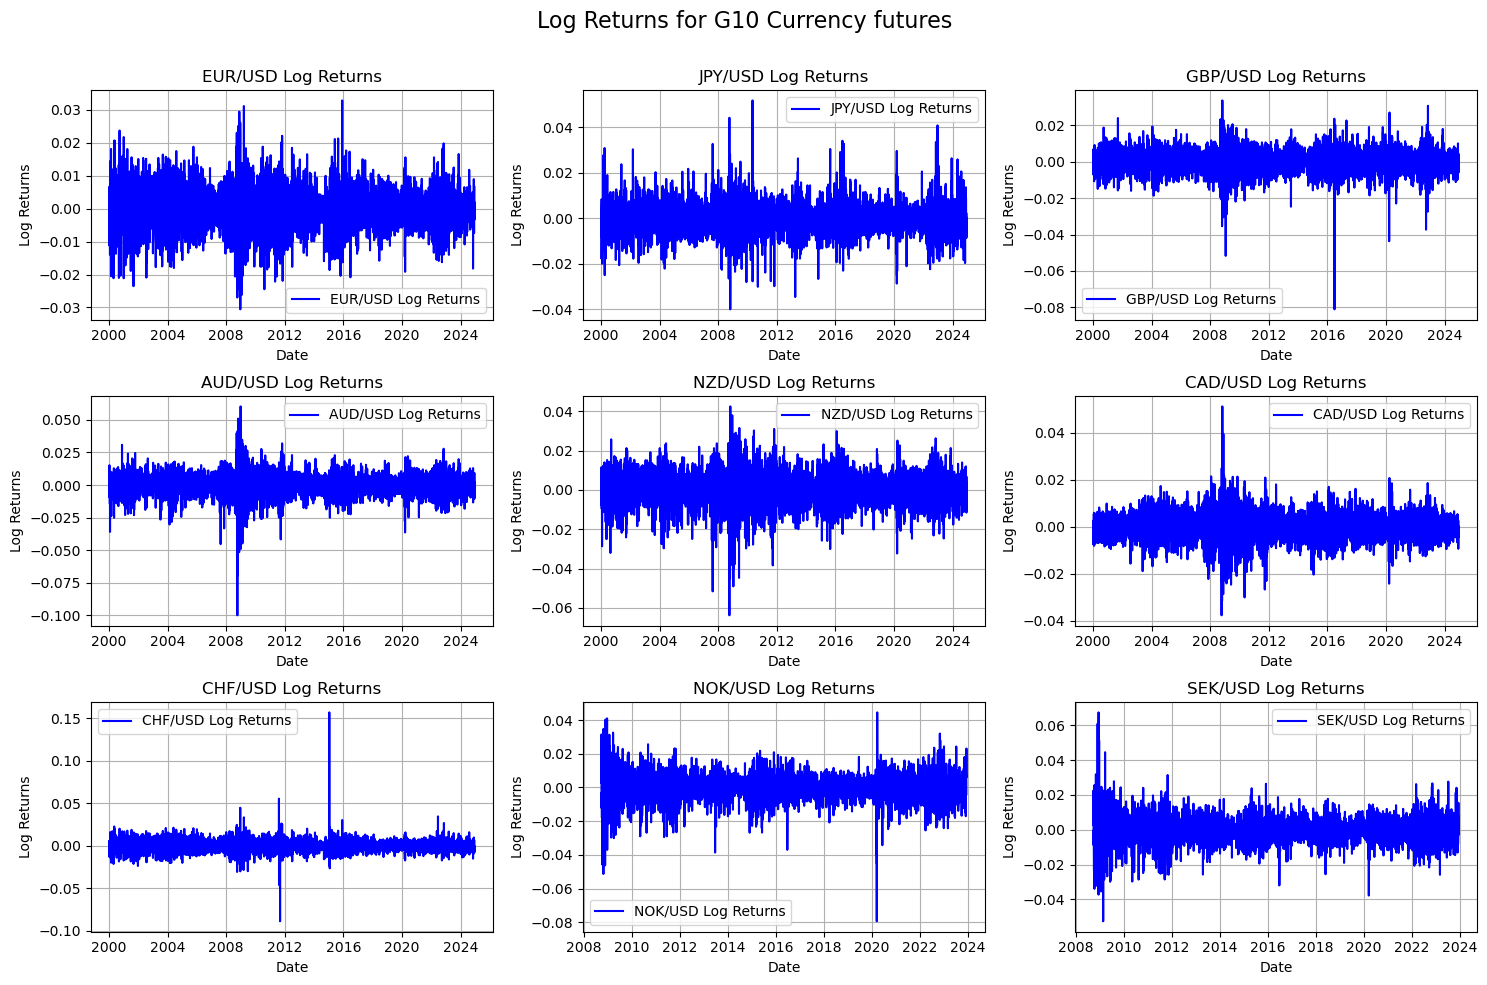

In [28]:
# Plotting log returns for all currencies (individual subplots)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
fig.suptitle('Log Returns for G10 Currency futures', fontsize=16)

# Flatten the axes array to iterate over it easily
axes = axes.flatten()

# Plot each currency's log returns
for i, (currency, log_returns) in enumerate(rolled_series_open.items()):
    curr_value = list(currencies.keys())[list(currencies.values()).index(currency)]
    axes[i].plot(log_returns, label=f'{curr_value}/USD Log Returns', color='blue')
    axes[i].set_title(f'{curr_value}/USD Log Returns')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Log Returns')
    axes[i].grid(True)
    axes[i].legend()

# Adjust layout for better readability
plt.tight_layout()
plt.subplots_adjust(top=0.9)  # Adjust the title spacing
plt.show()


Overlaying all the rolled returns on the same plot

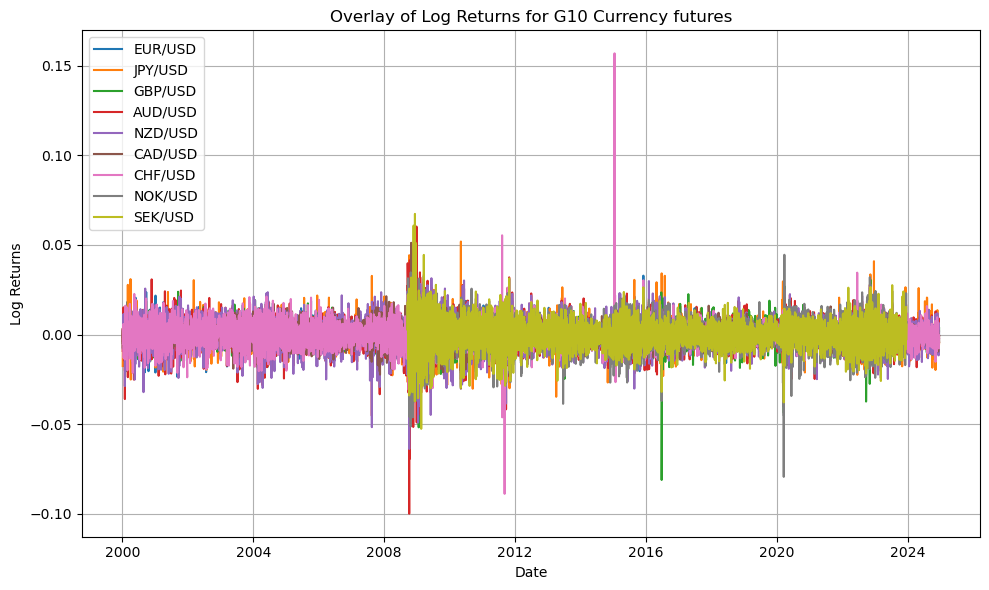

In [29]:
# Plotting all currencies' log returns in a single overlay plot
plt.figure(figsize=(10, 6))
for currency, log_returns in rolled_series_open.items():
    curr_value = list(currencies.keys())[list(currencies.values()).index(currency)]
    plt.plot(log_returns, label=f'{curr_value}/USD')
    
plt.title('Overlay of Log Returns for G10 Currency futures')
plt.xlabel('Date')
plt.ylabel('Log Returns')
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

Let us also plot the histograms of the rolled returns for various currencies to see if they are approximately normal

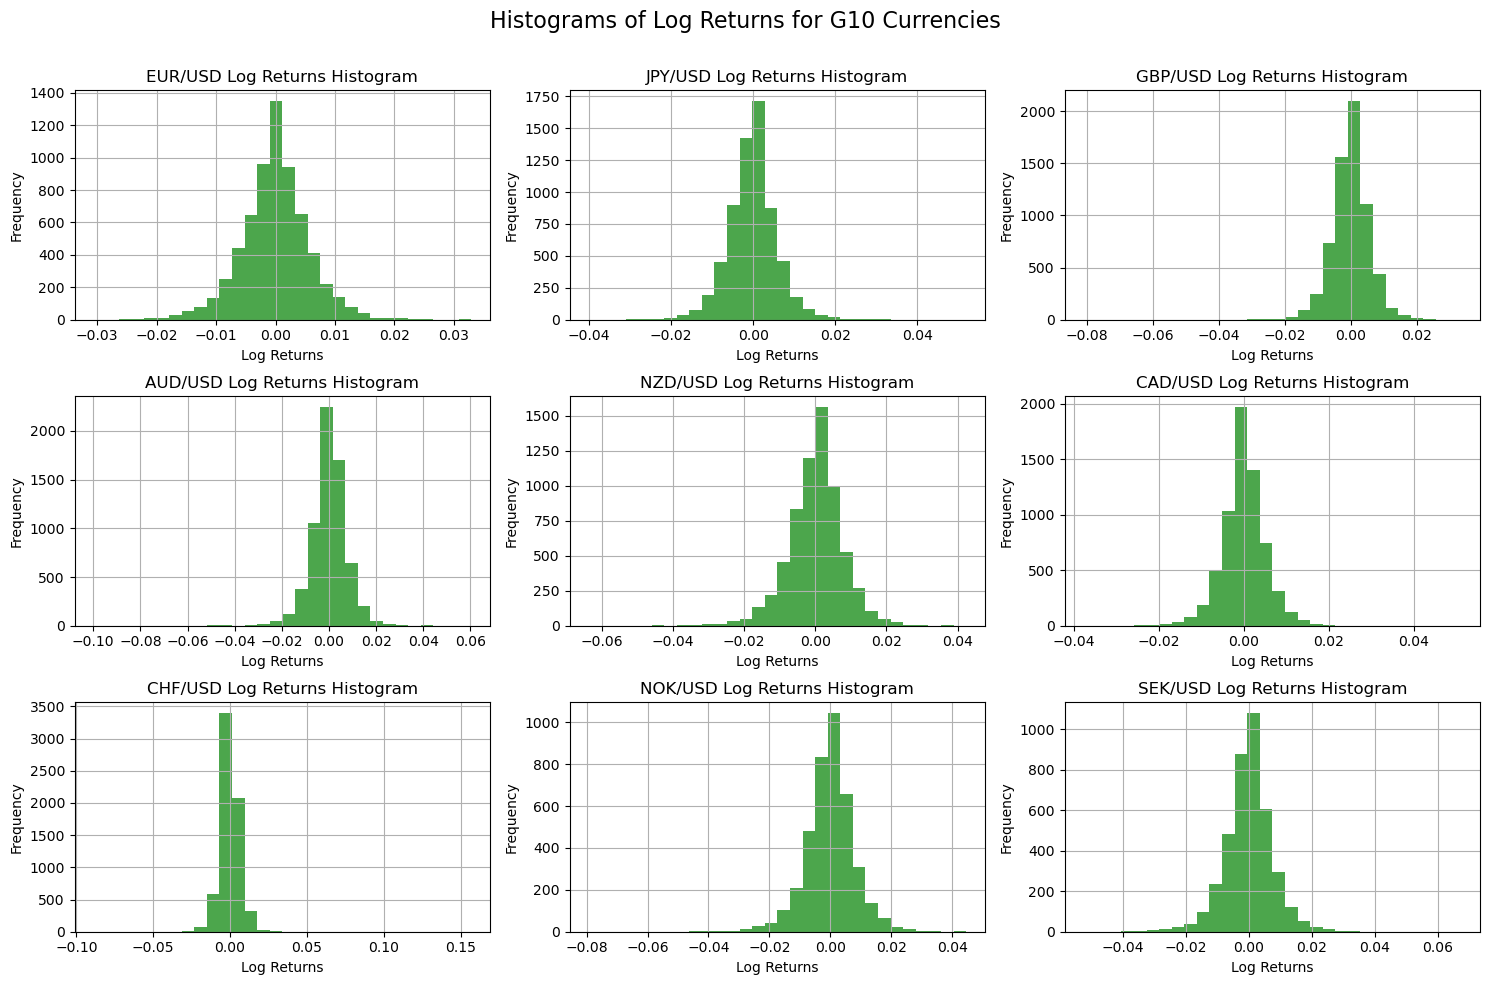

In [30]:
# Plotting histograms for all currencies
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
fig.suptitle('Histograms of Log Returns for G10 Currencies', fontsize=16)

axes = axes.flatten()

for i, (currency, log_returns) in enumerate(rolled_series_open.items()):
    axes[i].hist(log_returns, bins=30, color='green', alpha=0.7)
    curr_value = list(currencies.keys())[list(currencies.values()).index(currency)]
    axes[i].set_title(f'{curr_value}/USD Log Returns Histogram')
    axes[i].set_xlabel('Log Returns')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

We will also plot the rolling volatility for the futures contracts with a 30 day window

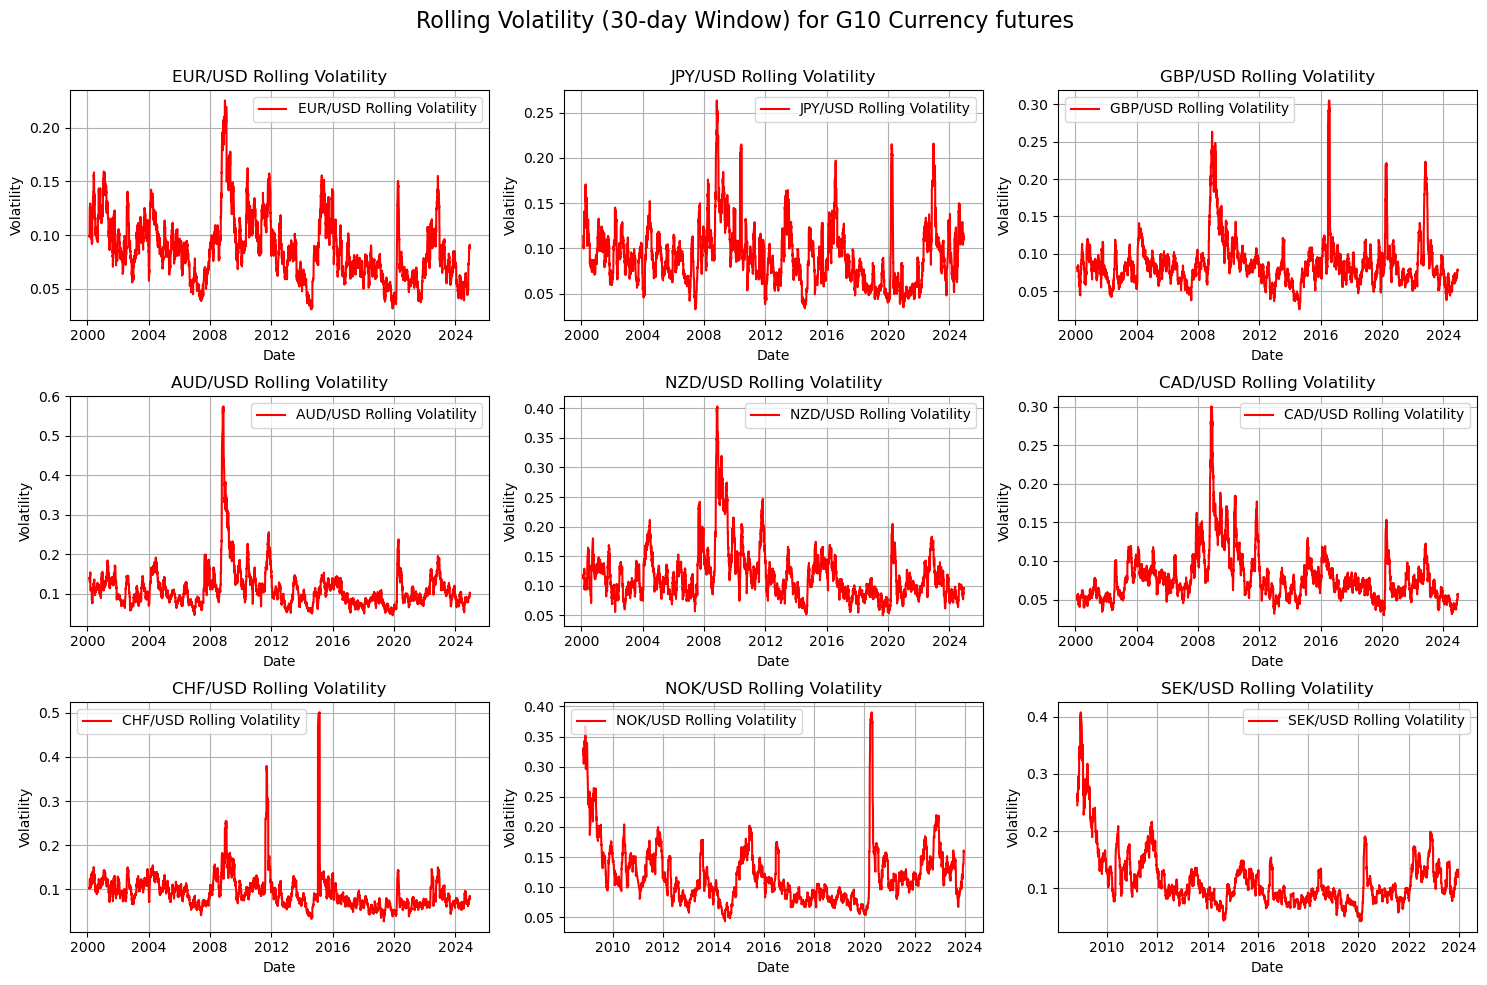

In [31]:
# Plotting rolling volatility (e.g., 30-day rolling window) for all currencies
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
fig.suptitle('Rolling Volatility (30-day Window) for G10 Currency futures', fontsize=16)

axes = axes.flatten()

for i, (currency, log_returns) in enumerate(rolled_series_open.items()):
    rolling_volatility = log_returns.rolling(window=30).std() * np.sqrt(260)
    curr_value = list(currencies.keys())[list(currencies.values()).index(currency)]
    axes[i].plot(rolling_volatility.dropna(), label=f'{curr_value}/USD Rolling Volatility', color='red')
    axes[i].set_title(f'{curr_value}/USD Rolling Volatility')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Volatility')
    axes[i].grid(True)
    axes[i].legend()

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

We will now look at how correlated the log returns are between the volume and the open interest rolling series

In [32]:
for code in currencies.values():
    corr = rolled_series[code].corr(rolled_series_open[code])
    curr_value = list(currencies.keys())[list(currencies.values()).index(code)]
    print(f'The correlation between volume and open interest rolled log returns for {curr_value}/USD is {corr}.')

The correlation between volume and open interest rolled log returns for EUR/USD is 0.9999775260994249.
The correlation between volume and open interest rolled log returns for JPY/USD is 0.9997340714493054.
The correlation between volume and open interest rolled log returns for GBP/USD is 0.999989046228334.
The correlation between volume and open interest rolled log returns for AUD/USD is 0.9997226174040008.
The correlation between volume and open interest rolled log returns for NZD/USD is 0.9993746770506674.
The correlation between volume and open interest rolled log returns for CAD/USD is 0.9993894168071812.
The correlation between volume and open interest rolled log returns for CHF/USD is 0.9999250831365623.
The correlation between volume and open interest rolled log returns for NOK/USD is 0.9999584932429951.
The correlation between volume and open interest rolled log returns for SEK/USD is 0.999845250071434.


In [33]:
# Convert rolled_series dictionary into a DataFrame with ISO currency codes
df_rolled_series = pd.DataFrame(rolled_series)

# Rename columns to ISO currency pairs (e.g., EUR/USD, JPY/USD)
df_rolled_series.columns = [f"{iso}/USD" for iso in currencies.keys()]

# Restrict data to only dates up to January 1, 2025
df_rolled_series = df_rolled_series[df_rolled_series.index <= "2025-01-01"]

# Save to CSV for inspection
df_rolled_series.to_csv('g10_futures_rolled_returns.csv')

print("Rolled futures returns DataFrame created successfully.")


Rolled futures returns DataFrame created successfully.


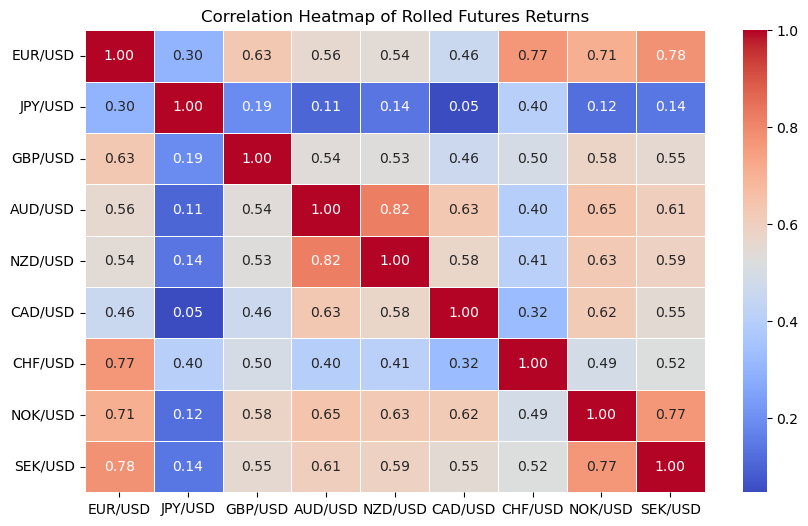

In [34]:
# Compute correlation matrix
corr_matrix = df_rolled_series.corr()

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

# Titles and labels
plt.title("Correlation Heatmap of Rolled Futures Returns")
plt.show()


In [35]:
# Convert rolled_series dictionary into a DataFrame with ISO currency codes
df_rolled_series_open = pd.DataFrame(rolled_series_open)

# Rename columns to ISO currency pairs (e.g., EUR/USD, JPY/USD)
df_rolled_series_open.columns = [f"{iso}/USD" for iso in currencies.keys()]

# Restrict data to only dates up to January 1, 2025
df_rolled_series_open = df_rolled_series_open[df_rolled_series_open.index <= "2025-01-01"]

# Save to CSV for inspection
df_rolled_series_open.to_csv('g10_futures_rolled_returns.csv')

print("Rolled futures returns DataFrame created successfully.")


Rolled futures returns DataFrame created successfully.


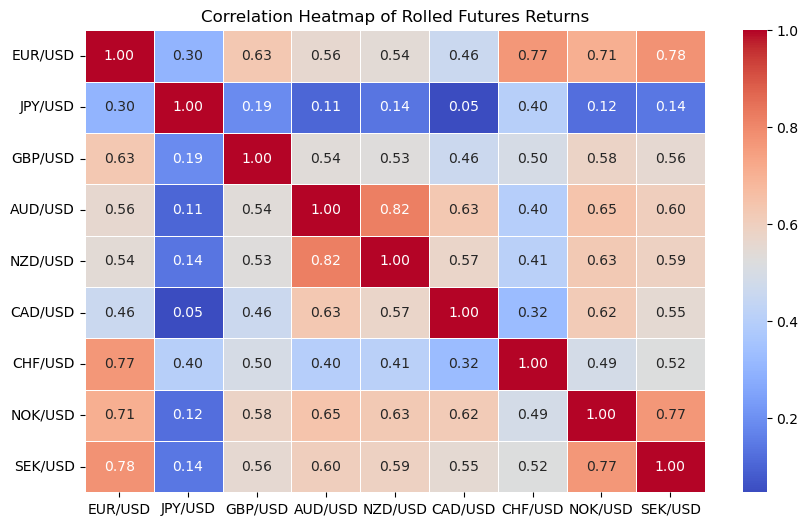

In [36]:
# Compute correlation matrix
corr_matrix = df_rolled_series_open.corr()

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

# Titles and labels
plt.title("Correlation Heatmap of Rolled Futures Returns")
plt.show()

### Observations from the Correlation Map  

From the correlation map, I can observe that the **European currency futures** (EUR, SEK, NOK, GBP, CHF - slightly less) are **heavily correlated** with each other. This could be because **European economies are highly interconnected**, along with their **strong trade ties** between each other.  

The **Japanese Yen (JPY)** seems to be **least correlated** with all other currencies. This could be due to the fact that it is a **safe-haven currency** and also because the **Bank of Japan's monetary policy** is entirely different—for example, maintaining **low interest rates**.  

**AUD and NZD** are again **heavily correlated**, as they have **strong trade ties** being neighboring countries. I also suspect that **AUD and NZD currency futures** would also be correlated with the **CNY (Chinese Yuan)** since **China is their biggest trading partner**.  

The **Canadian Dollar (CAD)** seems to have a **higher correlation with AUD and NZD** compared to others. One of **Canada's largest exports is oil**, and it might also be **heavily correlated** if we looked at **oil futures and CAD/USD futures**.  
